In [ ]:
!pip install pandas numpy opencv-python matplotlib

In [2]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

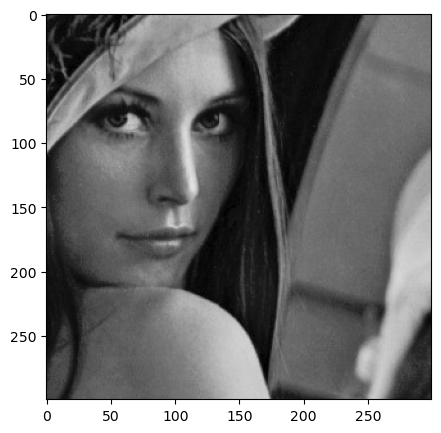

In [3]:
img = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\lena.tif")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)

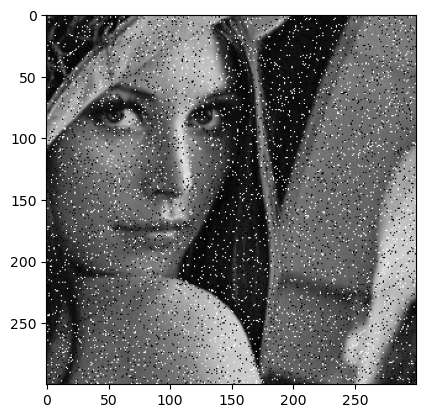

In [4]:
def salt_pepper(img, prob = 0.08):
    noisy = img.copy()
    h,w = img.shape[:2]
    for i in range(h):
        for j in range(w):
            r = np.random.rand()
            if r<prob/2:
                noisy[i,j] = 0
            elif r<prob:
                noisy[i,j] = 255
    return noisy
sp = salt_pepper(img)
plt.imshow(sp)


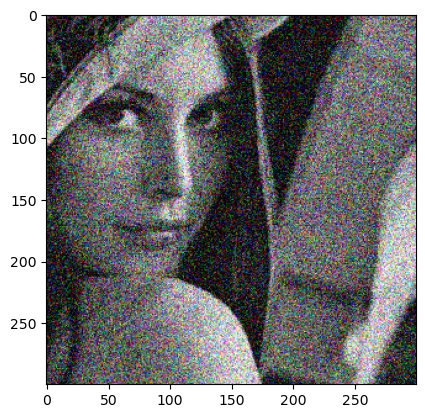

In [5]:
def gauss_noise(img, sigma=50):
    gauss = np.random.normal(0, sigma, img.shape)
    noisy = img + gauss
    noisy = np.clip(noisy, 0,255)
    return noisy.astype('uint8')

gn =gauss_noise(img)
plt.imshow(gn)

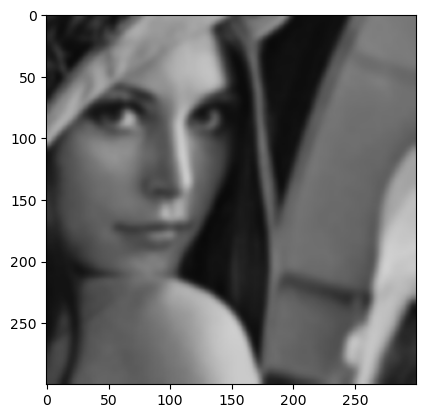

In [7]:
def blur_noise(img, k =15):
    return cv2.GaussianBlur(img, (k,k), 0)

blr= blur_noise(img, k=15)
plt.imshow(blr)

In [8]:
def mse(original,noisy):
    return np.mean((original-noisy)**2)
def psnr(original,noisy):
    m = mse(original,noisy)
    if m ==0:
        return 100
    return 20 * math.log10(255/math.sqrt(m))

In [10]:
print("MSE=", mse(img,sp))
print("PSNR=", psnr(img,sp))

MSE= 9.046677777777777
PSNR= 38.56591238863934
